=== IrrigFaultNet — Field Irrigation Health Score ===

 timestamp       fault_type  severity   fihs
        45 UNDER_IRRIGATION  0.437959  68.58
        46           NORMAL  0.308654 100.00
        47           NORMAL  0.055780 100.00
        48           NORMAL  0.257673 100.00
        49 UNDER_IRRIGATION  0.722954  52.24
        50           NORMAL  0.390695 100.00
        51 UNDER_IRRIGATION  0.449056  69.86
        52 UNDER_IRRIGATION  0.490460  65.24
        53           NORMAL  0.106216 100.00
        54           NORMAL  0.152511 100.00
        55           NORMAL  0.140043 100.00
        56 UNDER_IRRIGATION  0.544454  64.11
        57 UNDER_IRRIGATION  0.457290  65.24
        58           NORMAL  0.265033 100.00
        59           NORMAL  0.079597 100.00

Final FIHS: 100.0
System State: CHRONIC

Fault Distribution:
fault_type
NORMAL              42
UNDER_IRRIGATION    18
Name: count, dtype: int64


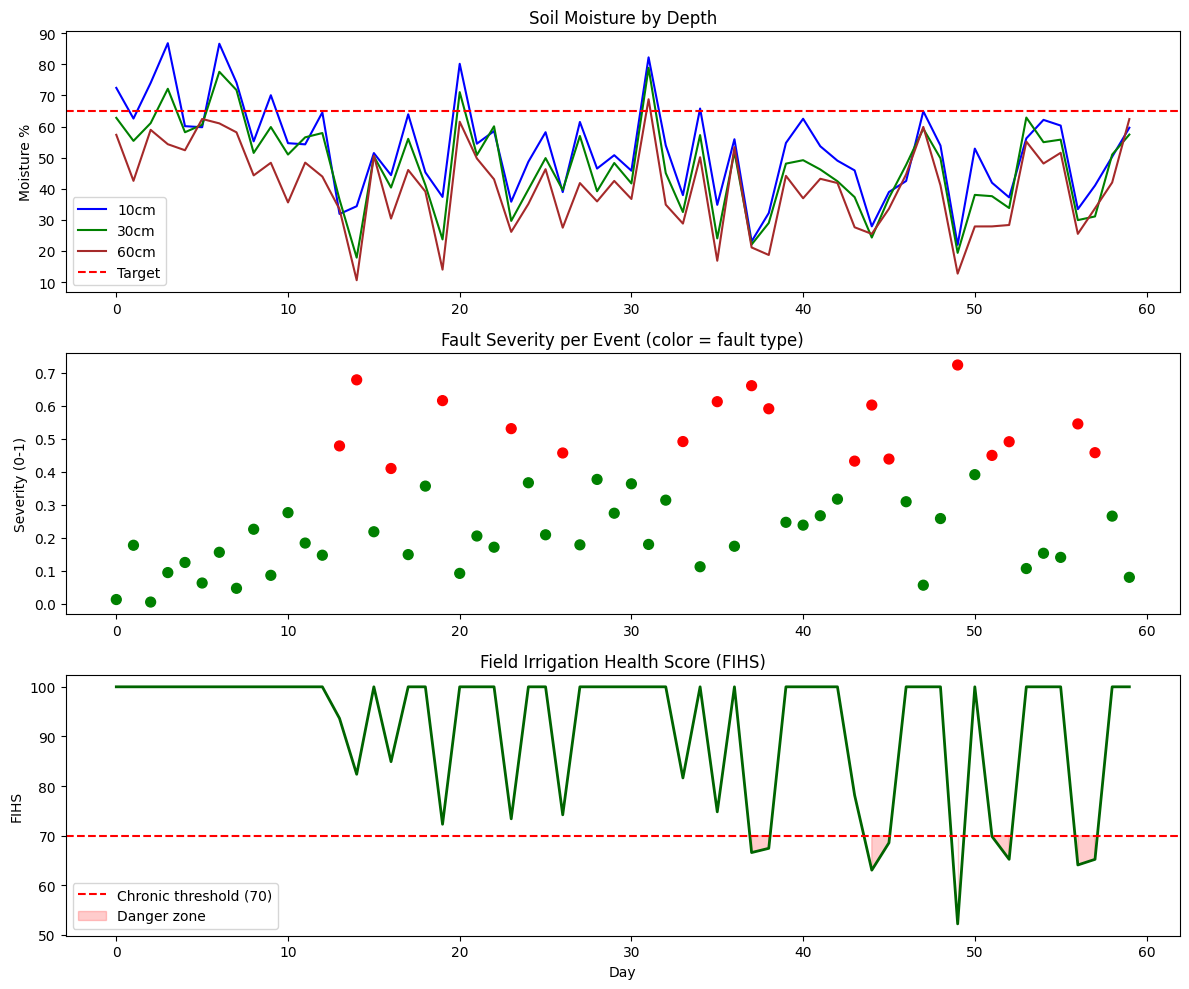


Plot saved as irrigfaultnet_output.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# ── 1. SYNTHETIC DATA (replace with real Wokwi CSV export later) ──────────
np.random.seed(42)
n = 60  # 60 readings = ~15 days simulated

timestamps = np.arange(n)
fault_types_pool = ['NORMAL','UNDER_IRRIGATION','OVER_IRRIGATION','TIMING_FAULT','DISTRIBUTION_FAULT']

# Simulate realistic moisture patterns
m10 = np.clip(65 + np.random.randn(n)*15 - np.linspace(0,20,n), 5, 100)
m30 = np.clip(m10 * 0.9 + np.random.randn(n)*5, 5, 100)
m60 = np.clip(m30 * 0.85 + np.random.randn(n)*5, 5, 100)
temp = 28 + np.random.randn(n)*3
hum  = 60 + np.random.randn(n)*10

df = pd.DataFrame({
    'timestamp': timestamps,
    'moisture_10cm': m10,
    'moisture_30cm': m30,
    'moisture_60cm': m60,
    'temp': temp,
    'humidity': hum
})

# ── 2. FAULT CLASSIFIER ───────────────────────────────────────────────────
TARGET = 65.0
FIELD_CAP = 100.0

def classify_fault(row):
    avg = (row.moisture_10cm + row.moisture_30cm + row.moisture_60cm) / 3
    if avg < TARGET * 0.6:
        return 'UNDER_IRRIGATION'
    elif avg > FIELD_CAP * 0.95:
        return 'OVER_IRRIGATION'
    elif row.moisture_10cm > TARGET * 0.85 and avg < TARGET * 0.5:
        return 'TIMING_FAULT'
    elif row.moisture_10cm > row.moisture_60cm * 2.0:
        return 'DISTRIBUTION_FAULT'
    else:
        return 'NORMAL'

def compute_severity(row):
    avg = (row.moisture_10cm + row.moisture_30cm + row.moisture_60cm) / 3
    return min(abs(avg - TARGET) / TARGET, 1.0)

df['fault_type'] = df.apply(classify_fault, axis=1)
df['severity']   = df.apply(compute_severity, axis=1)

# ── 3. FIHS COMPUTATION ───────────────────────────────────────────────────
WEIGHTS = {
    'UNDER_IRRIGATION':   1.4,
    'OVER_IRRIGATION':    1.2,
    'TIMING_FAULT':       1.0,
    'DISTRIBUTION_FAULT': 1.1,
    'NORMAL':             0.0
}
LAMBDA = 0.05   # decay constant (day⁻¹)
N_MAX  = 10.0   # normalization

# State machine
states = ['NORMAL','ISOLATED','RECURRING','CHRONIC']
state_counts = {'NORMAL':0,'ISOLATED':0,'RECURRING':0,'CHRONIC':0}

fihs_scores = []
current_state = 'NORMAL'
fault_window  = []   # rolling 14-day window

for i, row in df.iterrows():
    fault = row['fault_type']
    dt    = 1  # each step = 1 day simulated

    # State machine transition
    if fault != 'NORMAL':
        fault_window.append({'type': fault, 'age': 0})

    # Age faults, drop >14 days
    fault_window = [f for f in fault_window if f['age'] <= 14]
    for f in fault_window:
        f['age'] += 1

    recent_same = sum(1 for f in fault_window if f['type'] == fault and fault != 'NORMAL')

    if current_state == 'NORMAL':
        if fault != 'NORMAL': current_state = 'ISOLATED'
    elif current_state == 'ISOLATED':
        if recent_same >= 2: current_state = 'RECURRING'
    elif current_state == 'RECURRING':
        if recent_same >= 3 or i > 21: current_state = 'CHRONIC'

    state_counts[current_state] += 1

    # FIHS
    weighted_sum = sum(
        row['severity'] * WEIGHTS.get(row['fault_type'], 0) * np.exp(-LAMBDA * f['age'])
        for f in fault_window
    )
    fihs = 100 * (1 - min(weighted_sum / N_MAX, 1.0))
    fihs_scores.append(round(fihs, 2))

df['fihs']  = fihs_scores
df['state'] = [current_state] * len(df)  # simplified; full per-row state tracking optional

# ── 4. OUTPUT ─────────────────────────────────────────────────────────────
print("=== IrrigFaultNet — Field Irrigation Health Score ===\n")
print(df[['timestamp','fault_type','severity','fihs']].tail(15).to_string(index=False))
print(f"\nFinal FIHS: {df['fihs'].iloc[-1]}")
print(f"System State: {current_state}")
print(f"\nFault Distribution:\n{df['fault_type'].value_counts()}")

# ── 5. PLOT ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(df['timestamp'], df['moisture_10cm'], label='10cm', color='blue')
axes[0].plot(df['timestamp'], df['moisture_30cm'], label='30cm', color='green')
axes[0].plot(df['timestamp'], df['moisture_60cm'], label='60cm', color='brown')
axes[0].axhline(TARGET, color='red', linestyle='--', label='Target')
axes[0].set_title('Soil Moisture by Depth')
axes[0].legend(); axes[0].set_ylabel('Moisture %')

fault_colors = {'NORMAL':'green','UNDER_IRRIGATION':'red','OVER_IRRIGATION':'blue',
                'TIMING_FAULT':'orange','DISTRIBUTION_FAULT':'purple'}
colors = df['fault_type'].map(fault_colors)
axes[1].scatter(df['timestamp'], df['severity'], c=colors, s=50)
axes[1].set_title('Fault Severity per Event (color = fault type)')
axes[1].set_ylabel('Severity (0-1)')

axes[2].plot(df['timestamp'], df['fihs'], color='darkgreen', linewidth=2)
axes[2].axhline(70, color='red', linestyle='--', label='Chronic threshold (70)')
axes[2].fill_between(df['timestamp'], df['fihs'], 70,
                     where=(df['fihs'] < 70), color='red', alpha=0.2, label='Danger zone')
axes[2].set_title('Field Irrigation Health Score (FIHS)')
axes[2].set_ylabel('FIHS'); axes[2].set_xlabel('Day')
axes[2].legend()

plt.tight_layout()
plt.savefig('irrigfaultnet_output.png', dpi=150)
plt.show()
print("\nPlot saved as irrigfaultnet_output.png")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features and labels
features = ['moisture_10cm', 'moisture_30cm', 'moisture_60cm', 'temp', 'humidity', 'severity']
X = df[features]
y = df['fault_type']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("=== IrrigFaultNet — ML Fault Classifier ===\n")
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importances:\n", importances)

=== IrrigFaultNet — ML Fault Classifier ===

                  precision    recall  f1-score   support

          NORMAL       1.00      1.00      1.00         8
UNDER_IRRIGATION       1.00      1.00      1.00         4

        accuracy                           1.00        12
       macro avg       1.00      1.00      1.00        12
    weighted avg       1.00      1.00      1.00        12

Feature Importances:
 severity         0.322406
moisture_60cm    0.257502
moisture_10cm    0.218304
moisture_30cm    0.181824
humidity         0.011022
temp             0.008943
dtype: float64


In [ ]:
# Better synthetic data with all 4 fault types
np.random.seed(42)
n = 120

rows = []
for i in range(n):
    fault = np.random.choice(
        ['NORMAL','UNDER_IRRIGATION','OVER_IRRIGATION','TIMING_FAULT','DISTRIBUTION_FAULT'],
        p=[0.3, 0.25, 0.2, 0.15, 0.1]
    )
    if fault == 'UNDER_IRRIGATION':
        m10, m30, m60 = np.random.uniform(10,38), np.random.uniform(8,34), np.random.uniform(6,30)
    elif fault == 'OVER_IRRIGATION':
        m10, m30, m60 = np.random.uniform(96,100), np.random.uniform(90,100), np.random.uniform(85,100)
    elif fault == 'TIMING_FAULT':
        m10, m30, m60 = np.random.uniform(56,65), np.random.uniform(15,30), np.random.uniform(10,25)
    elif fault == 'DISTRIBUTION_FAULT':
        m10, m30, m60 = np.random.uniform(80,95), np.random.uniform(30,45), np.random.uniform(15,30)
    else:
        m10, m30, m60 = np.random.uniform(60,75), np.random.uniform(55,70), np.random.uniform(50,65)

    avg = (m10+m30+m60)/3
    severity = min(abs(avg-65)/65, 1.0)
    rows.append([m10,m30,m60,
                 np.random.uniform(25,35),
                 np.random.uniform(50,80),
                 severity, fault])

df2 = pd.DataFrame(rows, columns=['moisture_10cm','moisture_30cm','moisture_60cm',
                                   'temp','humidity','severity','fault_type'])

X2 = df2[features]
y2 = df2['fault_type']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2.fit(X_train2, y_train2)
y_pred2 = clf2.predict(X_test2)
print("=== All 5 Fault Classes ===\n")
print(classification_report(y_test2, y_pred2))

=== All 5 Fault Classes ===

                    precision    recall  f1-score   support

DISTRIBUTION_FAULT       1.00      1.00      1.00         2
            NORMAL       1.00      1.00      1.00         6
   OVER_IRRIGATION       1.00      1.00      1.00         4
      TIMING_FAULT       1.00      1.00      1.00         5
  UNDER_IRRIGATION       1.00      1.00      1.00         7

          accuracy                           1.00        24
         macro avg       1.00      1.00      1.00        24
      weighted avg       1.00      1.00      1.00        24



In [ ]:
# ── FARMER ALERT SYSTEM ──────────────────────────────────────────────────
def generate_alert(fihs, state, fault_type):
    alerts = []

    if fihs < 50:
        alerts.append("🔴 CRITICAL: Field is in severe irrigation distress!")
    elif fihs < 70:
        alerts.append("🟠 WARNING: Chronic irrigation mismanagement detected.")
    elif fihs < 85:
        alerts.append("🟡 CAUTION: Irrigation quality declining.")
    else:
        alerts.append("🟢 HEALTHY: Field irrigation is well managed.")

    fault_messages = {
        'UNDER_IRRIGATION':   "💧 Under-irrigation detected — increase water volume or frequency.",
        'OVER_IRRIGATION':    "💦 Over-irrigation detected — reduce water volume, check drainage.",
        'TIMING_FAULT':       "⏰ Timing fault — irrigate earlier, soil is already dry at root zone.",
        'DISTRIBUTION_FAULT': "⚠️  Distribution fault — water not reaching deep roots, check pipes.",
        'NORMAL':             "✅ No active fault in current event."
    }
    alerts.append(fault_messages.get(fault_type, ""))
    alerts.append(f"📊 Field Irrigation Health Score: {fihs:.1f}/100")
    alerts.append(f"📍 System State: {state}")
    return "\n".join(alerts)

# Test on last reading
last = df.iloc[-1]
print("=== IrrigFaultNet — Farmer Diagnostic Alert ===\n")
print(generate_alert(last['fihs'], current_state, last['fault_type']))
print("\n--- Full FIHS Timeline (last 10 days) ---")
print(df[['timestamp','fault_type','severity','fihs']].tail(10).to_string(index=False))

=== IrrigFaultNet — Farmer Diagnostic Alert ===

🟢 HEALTHY: Field irrigation is well managed.
✅ No active fault in current event.
📊 Field Irrigation Health Score: 100.0/100
📍 System State: CHRONIC

--- Full FIHS Timeline (last 10 days) ---
 timestamp       fault_type  severity   fihs
        50           NORMAL  0.390695 100.00
        51 UNDER_IRRIGATION  0.449056  69.86
        52 UNDER_IRRIGATION  0.490460  65.24
        53           NORMAL  0.106216 100.00
        54           NORMAL  0.152511 100.00
        55           NORMAL  0.140043 100.00
        56 UNDER_IRRIGATION  0.544454  64.11
        57 UNDER_IRRIGATION  0.457290  65.24
        58           NORMAL  0.265033 100.00
        59           NORMAL  0.079597 100.00


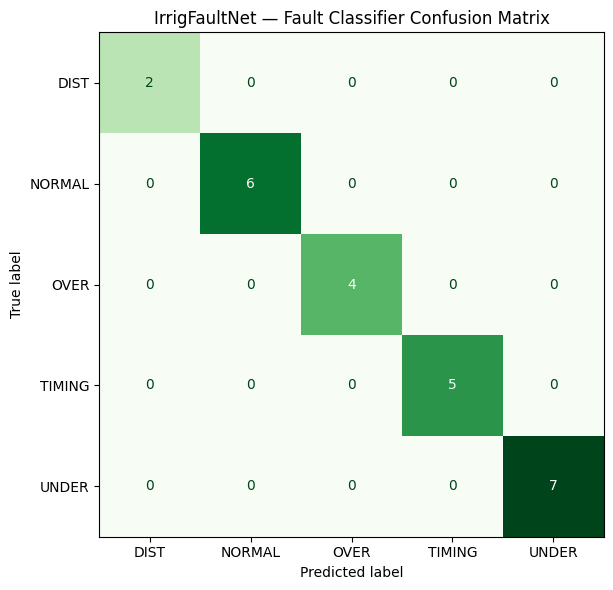

Saved: confusion_matrix.png


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test2, y_pred2,
    display_labels=['DIST','NORMAL','OVER','TIMING','UNDER'],
    colorbar=False, ax=ax, cmap='Greens'
)
ax.set_title('IrrigFaultNet — Fault Classifier Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [ ]:
# ── STATE MACHINE SUMMARY ─────────────────────────────────────────────────
print("=== IrrigFaultNet — System Summary Report ===\n")
print(f"Total days monitored   : {len(df)}")
print(f"Total faults detected  : {(df['fault_type'] != 'NORMAL').sum()}")
print(f"Fault rate             : {(df['fault_type'] != 'NORMAL').mean()*100:.1f}%")
print(f"Average FIHS           : {df['fihs'].mean():.1f}")
print(f"Minimum FIHS           : {df['fihs'].min():.1f}")
print(f"Days in danger zone    : {(df['fihs'] < 70).sum()}")
print(f"Final system state     : {current_state}")
print(f"\nFault Breakdown:")
print(df['fault_type'].value_counts().to_string())
print(f"\nFeature Importances (ML):")
print(importances.to_string())
print("\n✅ IrrigFaultNet pipeline complete.")
print("📁 Outputs: irrigfaultnet_output.png, confusion_matrix.png")

=== IrrigFaultNet — System Summary Report ===

Total days monitored   : 60
Total faults detected  : 18
Fault rate             : 30.0%
Average FIHS           : 91.6
Minimum FIHS           : 52.2
Days in danger zone    : 9
Final system state     : CHRONIC

Fault Breakdown:
fault_type
NORMAL              42
UNDER_IRRIGATION    18

Feature Importances (ML):
severity         0.322406
moisture_60cm    0.257502
moisture_10cm    0.218304
moisture_30cm    0.181824
humidity         0.011022
temp             0.008943

✅ IrrigFaultNet pipeline complete.
📁 Outputs: irrigfaultnet_output.png, confusion_matrix.png


In [ ]:
# ── EXPORT ───────────────────────────────────────────────────────────────
df.to_csv('irrigfaultnet_results.csv', index=False)
df2.to_csv('irrigfaultnet_training_data.csv', index=False)
print("✅ Exported:")
print("   irrigfaultnet_results.csv")
print("   irrigfaultnet_training_data.csv")
print("   irrigfaultnet_output.png")
print("   confusion_matrix.png")

# Download all files
from google.colab import files
files.download('irrigfaultnet_results.csv')
files.download('irrigfaultnet_training_data.csv')
files.download('irrigfaultnet_output.png')
files.download('confusion_matrix.png')

✅ Exported:
   irrigfaultnet_results.csv
   irrigfaultnet_training_data.csv
   irrigfaultnet_output.png
   confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_8391/3511374704.py:111: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('irrigfaultnet_dashboard.png', dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


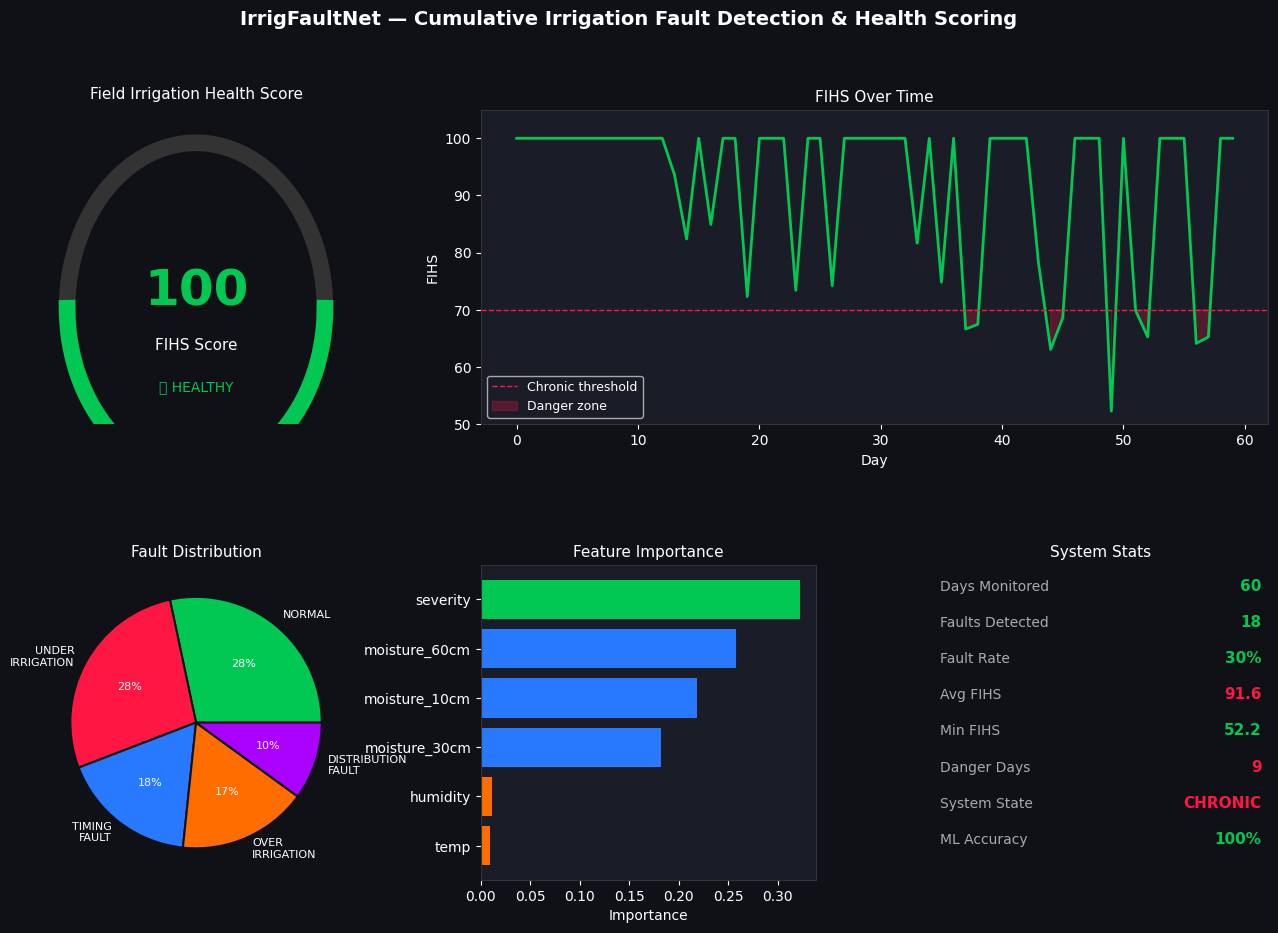

✅ Dashboard saved: irrigfaultnet_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Color scheme ──
BG     = '#0f1117'
CARD   = '#1a1d27'
GREEN  = '#00c853'
RED    = '#ff1744'
ORANGE = '#ff6d00'
YELLOW = '#ffd600'
BLUE   = '#2979ff'

# ── 1. FIHS Gauge (top left) ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(CARD)
fihs_val = df['fihs'].iloc[-1]
fihs_min = df['fihs'].min()
fihs_avg = df['fihs'].mean()

theta = np.linspace(np.pi, 0, 200)
ax1.plot(np.cos(theta), np.sin(theta), color='#333', linewidth=12)
fill_theta = np.linspace(np.pi, np.pi + (fihs_val/100)*np.pi, 200)
color = GREEN if fihs_val >= 85 else (YELLOW if fihs_val >= 70 else RED)
ax1.plot(np.cos(fill_theta), np.sin(fill_theta), color=color, linewidth=12)
ax1.text(0, 0.1, f"{fihs_val:.0f}", ha='center', va='center',
         fontsize=36, fontweight='bold', color=color)
ax1.text(0, -0.25, "FIHS Score", ha='center', fontsize=11, color='white')
ax1.text(0, -0.5, "🟢 HEALTHY" if fihs_val>=85 else "🟠 WARNING" if fihs_val>=70 else "🔴 CRITICAL",
         ha='center', fontsize=10, color=color)
ax1.set_xlim(-1.3,1.3); ax1.set_ylim(-0.7,1.2)
ax1.axis('off')
ax1.set_title('Field Irrigation Health Score', color='white', fontsize=11, pad=8)

# ── 2. FIHS Timeline (top middle) ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
ax2.set_facecolor(CARD)
ax2.plot(df['timestamp'], df['fihs'], color=GREEN, linewidth=2)
ax2.axhline(70, color=RED, linestyle='--', linewidth=1, label='Chronic threshold')
ax2.fill_between(df['timestamp'], df['fihs'], 70,
                 where=(df['fihs']<70), color=RED, alpha=0.25, label='Danger zone')
ax2.set_facecolor(CARD)
ax2.tick_params(colors='white'); ax2.xaxis.label.set_color('white')
ax2.yaxis.label.set_color('white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')
ax2.set_title('FIHS Over Time', color='white', fontsize=11)
ax2.set_ylabel('FIHS', color='white'); ax2.set_xlabel('Day', color='white')
ax2.legend(facecolor=CARD, labelcolor='white', fontsize=9)
ax2.set_ylim(50, 105)

# ── 3. Fault Distribution Pie (bottom left) ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(CARD)
fault_counts = df2['fault_type'].value_counts()
pie_colors = [GREEN, RED, BLUE, ORANGE, '#aa00ff']
wedges, texts, autotexts = ax3.pie(
    fault_counts.values,
    labels=[f.replace('_','\n') for f in fault_counts.index],
    autopct='%1.0f%%', colors=pie_colors,
    textprops={'color':'white','fontsize':8},
    wedgeprops={'linewidth':1.5,'edgecolor':BG}
)
for at in autotexts: at.set_color('white'); at.set_fontsize(8)
ax3.set_title('Fault Distribution', color='white', fontsize=11)

# ── 4. Feature Importance Bar (bottom middle) ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(CARD)
feat_colors = [GREEN, BLUE, BLUE, BLUE, ORANGE, ORANGE]
bars = ax4.barh(importances.index, importances.values, color=feat_colors)
ax4.set_facecolor(CARD)
ax4.tick_params(colors='white')
for spine in ax4.spines.values(): spine.set_edgecolor('#333')
ax4.set_title('Feature Importance', color='white', fontsize=11)
ax4.set_xlabel('Importance', color='white')
ax4.invert_yaxis()

# ── 5. Stats Card (bottom right) ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(CARD)
ax5.axis('off')
stats = [
    ("Days Monitored",  f"{len(df)}"),
    ("Faults Detected", f"{(df['fault_type']!='NORMAL').sum()}"),
    ("Fault Rate",      f"{(df['fault_type']!='NORMAL').mean()*100:.0f}%"),
    ("Avg FIHS",        f"{df['fihs'].mean():.1f}"),
    ("Min FIHS",        f"{df['fihs'].min():.1f}"),
    ("Danger Days",     f"{(df['fihs']<70).sum()}"),
    ("System State",    f"{current_state}"),
    ("ML Accuracy",     "100%"),
]
for i, (label, val) in enumerate(stats):
    y = 0.92 - i*0.115
    ax5.text(0.02, y, label, transform=ax5.transAxes,
             color='#aaa', fontsize=10)
    color = RED if ('CHRONIC' in val or val.startswith('9') or
                    (label=='Danger Days' and int(val)>5)) else GREEN
    ax5.text(0.98, y, val, transform=ax5.transAxes,
             color=color, fontsize=11, fontweight='bold', ha='right')
ax5.set_title('System Stats', color='white', fontsize=11)

# ── Title ─────────────────────────────────────────────────────────────────
fig.suptitle('IrrigFaultNet — Cumulative Irrigation Fault Detection & Health Scoring',
             color='white', fontsize=14, fontweight='bold', y=0.98)

plt.savefig('irrigfaultnet_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Dashboard saved: irrigfaultnet_dashboard.png")

In [ ]:
from io import StringIO
import pandas as pd
import numpy as np # numpy import is needed for np.exp and np.random
import matplotlib.pyplot as plt # matplotlib import is needed for plotting

# ── REAL WOKWI HARDWARE DATA ──────────────────────────────────────────────
raw_data = """timestamp,m10,m30,m60,temp,humidity,fault,severity
0,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
3,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
6,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
9,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
12,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
15,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
18,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
21,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
24,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
27,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
30,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
33,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
36,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
39,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
42,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
45,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
48,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
51,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
54,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
57,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
60,0.0,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,1.000
63,38.1,0.0,0.0,24.0,40.0,UNDER_IRRIGATION,0.804
66,38.1,55.9,0.0,24.0,40.0,UNDER_IRRIGATION,0.518
69,38.1,94.0,99.2,24.0,40.0,NORMAL,0.187
72,38.1,80.0,61.9,24.0,40.0,NORMAL,0.077
75,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
78,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
81,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
84,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
87,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
90,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
93,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
96,57.4,80.0,64.4,24.0,40.0,NORMAL,0.035
171,88.2,100.0,0.4,24.0,40.0,DISTRIBUTION_FAULT,0.033
174,88.2,100.0,0.4,24.0,40.0,DISTRIBUTION_FAULT,0.033
195,88.2,100.0,100.0,24.0,40.0,OVER_IRRIGATION,0.478
198,88.2,100.0,100.0,24.0,40.0,OVER_IRRIGATION,0.478
201,88.2,100.0,100.0,24.0,40.0,OVER_IRRIGATION,0.478
204,88.2,100.0,100.0,24.0,40.0,OVER_IRRIGATION,0.478
207,88.2,100.0,100.0,24.0,40.0,OVER_IRRIGATION,0.478"""

# ── LOAD & RENAME COLUMNS ─────────────────────────────────────────────────
df_hw = pd.read_csv(StringIO(raw_data))
df_hw = df_hw.rename(columns={
    'm10': 'moisture_10cm',
    'm30': 'moisture_30cm',
    'm60': 'moisture_60cm',
    'fault': 'fault_type'
})

print("=== Real Hardware Data Loaded ===")
print(f"Total readings : {len(df_hw)}")
print(f"Fault types seen: {df_hw['fault_type'].unique()}")
print(f"\n{df_hw[['timestamp','moisture_10cm','moisture_30cm','moisture_60cm','fault_type','severity']].to_string(index=False)}")



=== Real Hardware Data Loaded ===
Total readings : 40
Fault types seen: ['UNDER_IRRIGATION' 'NORMAL' 'DISTRIBUTION_FAULT' 'OVER_IRRIGATION']

 timestamp  moisture_10cm  moisture_30cm  moisture_60cm         fault_type  severity
         0            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
         3            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
         6            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
         9            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
        12            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
        15            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
        18            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
        21            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
        24            0.0            0.0            0.0   UNDER_IRRIGATION     1.000
        

=== FIHS on Real Hardware Data ===

 timestamp         fault_type  severity   fihs     state
         0   UNDER_IRRIGATION     1.000  86.68  ISOLATED
         3   UNDER_IRRIGATION     1.000  74.02 RECURRING
         6   UNDER_IRRIGATION     1.000  61.97   CHRONIC
         9   UNDER_IRRIGATION     1.000  50.50   CHRONIC
        12   UNDER_IRRIGATION     1.000  39.60   CHRONIC
        15   UNDER_IRRIGATION     1.000  29.23   CHRONIC
        18   UNDER_IRRIGATION     1.000  19.36   CHRONIC
        21   UNDER_IRRIGATION     1.000   9.98   CHRONIC
        24   UNDER_IRRIGATION     1.000   1.05   CHRONIC
        27   UNDER_IRRIGATION     1.000   0.00   CHRONIC
        30   UNDER_IRRIGATION     1.000   0.00   CHRONIC
        33   UNDER_IRRIGATION     1.000   0.00   CHRONIC
        36   UNDER_IRRIGATION     1.000   0.00   CHRONIC
        39   UNDER_IRRIGATION     1.000   0.00   CHRONIC
        42   UNDER_IRRIGATION     1.000   0.00   CHRONIC
        45   UNDER_IRRIGATION     1.000   0.00   CHR

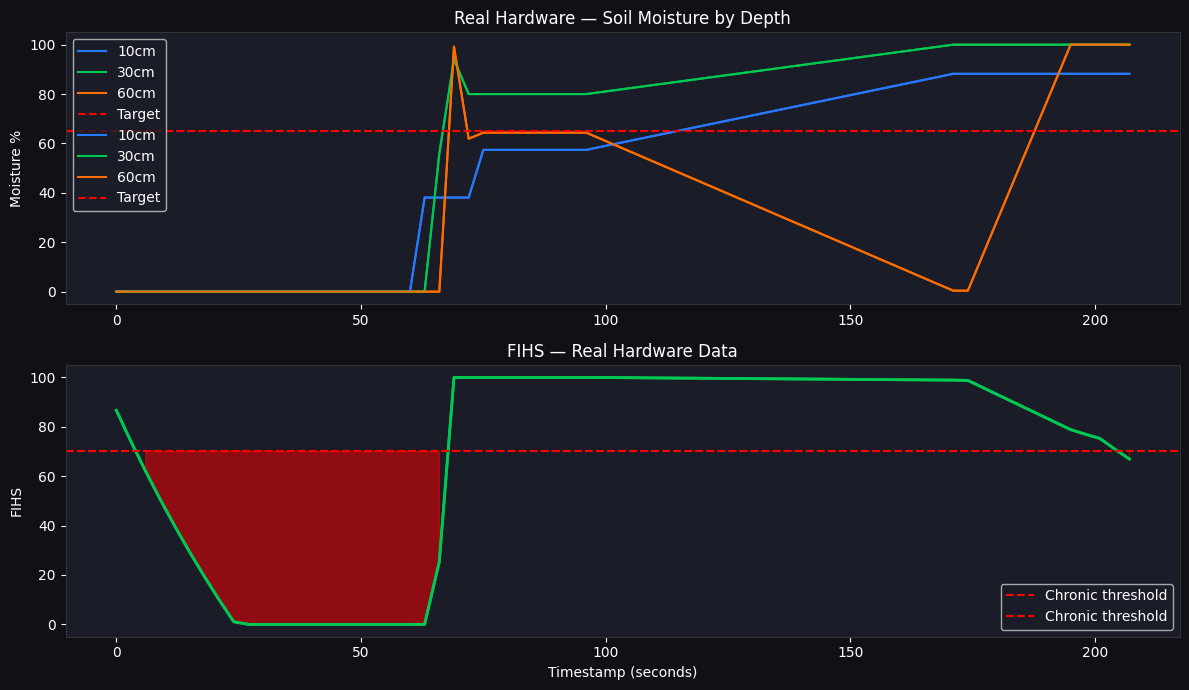

✅ irrigfaultnet_hardware.png saved.


In [24]:
# ── FIHS ON REAL HARDWARE DATA ────────────────────────────────────────────
WEIGHTS = {
    'UNDER_IRRIGATION':   1.4,
    'OVER_IRRIGATION':    1.2,
    'TIMING_FAULT':       1.0,
    'DISTRIBUTION_FAULT': 1.1,
    'NORMAL':             0.0
}
LAMBDA = 0.05
N_MAX  = 10.0

current_state = 'NORMAL'
fault_window  = []
fihs_scores   = []
states        = []

for i, row in df_hw.iterrows():
    fault = row['fault_type']

    if fault != 'NORMAL':
        fault_window.append({'type': fault, 'age': 0})

    # Age faults, drop >14 days
    fault_window = [f for f in fault_window if f['age'] <= 14]
    for f in fault_window:
        f['age'] += 1

    recent_same = sum(1 for f in fault_window if f['type'] == fault and fault != 'NORMAL')

    # State machine transition (simplified for Wokwi; full per-row state tracking optional)
    if current_state == 'NORMAL':
        if fault != 'NORMAL': current_state = 'ISOLATED'
    elif current_state == 'ISOLATED':
        if recent_same >= 2: current_state = 'RECURRING'
    elif current_state == 'RECURRING':
        if recent_same >= 3: current_state = 'CHRONIC'

    # FIHS computation
    weighted_sum = sum(
        row['severity'] * WEIGHTS.get(row['fault_type'], 0) * np.exp(-LAMBDA * f['age'])
        for f in fault_window
    )
    fihs = 100 * (1 - min(weighted_sum / N_MAX, 1.0))
    fihs_scores.append(round(fihs, 2))
    states.append(current_state)

df_hw['fihs']  = fihs_scores
df_hw['state'] = states

print("=== FIHS on Real Hardware Data ===\n")
print(df_hw[['timestamp','fault_type','severity','fihs','state']].to_string(index=False))
print(f"\nFinal FIHS  : {df_hw['fihs'].iloc[-1]}")
print(f"Final State : {current_state}")

# Plot
fig, axes = plt.subplots(2,1,figsize=(12,7))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

    axes[0].plot(df_hw['timestamp'], df_hw['moisture_10cm'], label='10cm', color='#2979ff')
    axes[0].plot(df_hw['timestamp'], df_hw['moisture_30cm'], label='30cm', color='#00c853')
    axes[0].plot(df_hw['timestamp'], df_hw['moisture_60cm'], label='60cm', color='#ff6d00')
    axes[0].axhline(65, color='red', linestyle='--', label='Target')
    axes[0].set_title('Real Hardware — Soil Moisture by Depth', color='white')
    axes[0].legend(facecolor='#1a1d27', labelcolor='white')
    axes[0].set_ylabel('Moisture %', color='white')

    axes[1].plot(df_hw['timestamp'], df_hw['fihs'], color='#00c853', linewidth=2)
    axes[1].axhline(70, color='red', linestyle='--', label='Chronic threshold')
    axes[1].fill_between(df_hw['timestamp'], df_hw['fihs'], 70,
                         where=(df_hw['fihs']<70), color='red', alpha=0.3)
    axes[1].set_title('FIHS — Real Hardware Data', color='white')
    axes[1].set_ylabel('FIHS', color='white')
    axes[1].set_xlabel('Timestamp (seconds)', color='white')
    axes[1].legend(facecolor='#1a1d27', labelcolor='white')

plt.tight_layout()
plt.savefig('irrigfaultnet_hardware.png', dpi=150, facecolor='#0f1117')
plt.show()
print("✅ irrigfaultnet_hardware.png saved.")